# Basics of Electromagnetic Waveguides

- Example for those with less physics background
- Light/Physics propergates as a plane wave in free space
- A waveguide creates standing waves with light by creating confinement on the scale of the wavelength 
- Many familiar waves (sound, water waves) are scalar quantities  
- These sorts of waves typically don't generate transverse propagation
- Electric and magnetic fields are coupled vector fields
- When you create a standing wave in one dimension you generate a traveling wave in another
- Consequently the electromagnetic energy is confined within a volume of space with descrete modes coresponding to the solutions of the 2D maxwells equations
- These solutions  
- Waveguides which are much larger than the wavelength of the em radation are governed by snells law 

# Waveguide modes


Assembling matrix for 14400 grid points...

and we are done (after 0.7750043869018555 secs).
Solving eigenmodes on CPU
0.483323335647583 secs later we have the final solution.


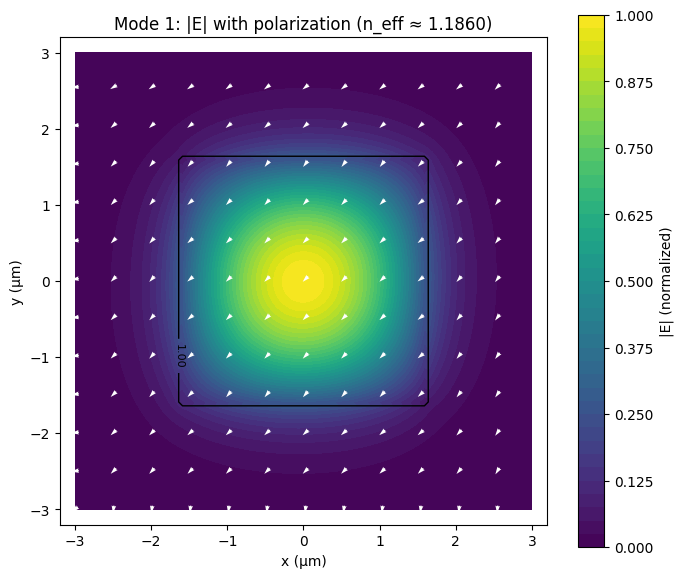

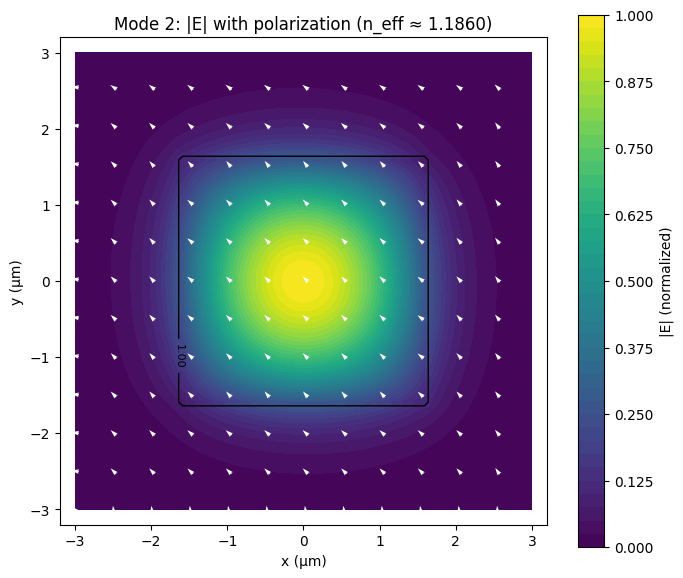

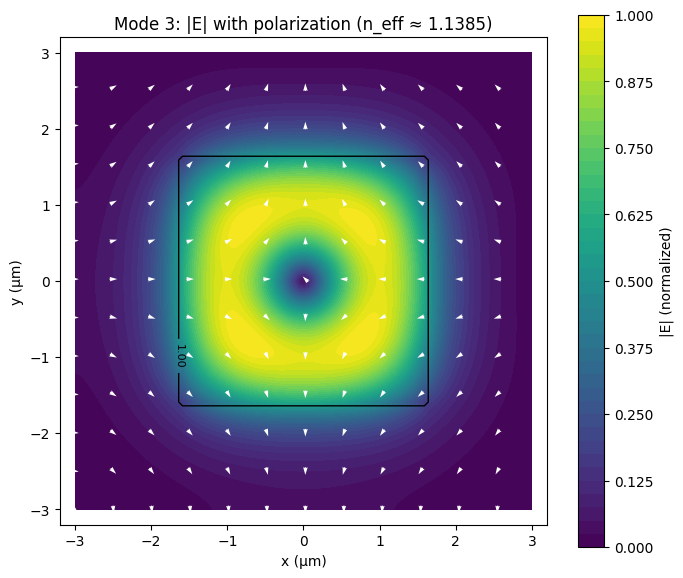

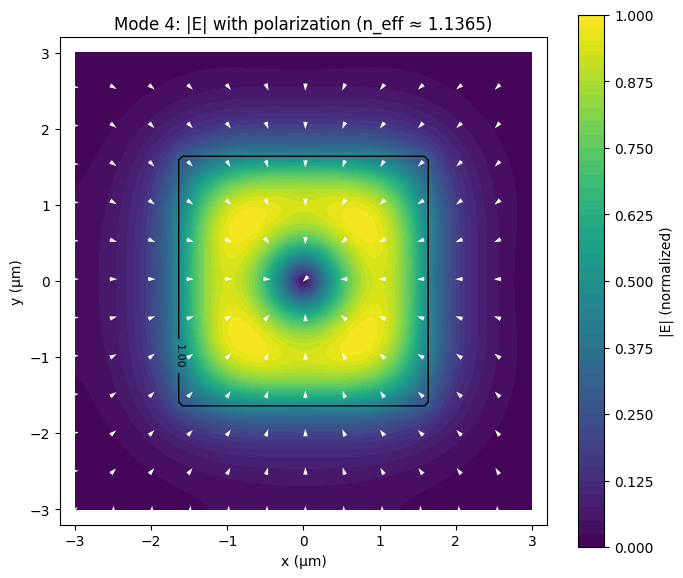

In [37]:
# Square step-index waveguide: first few modes with polarization arrows

import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as cst
import philsol as ps

# Domain and sampling
Lx_um, Ly_um = 3.0, 3.0
nx, ny = 120, 120

x = np.linspace(-Lx_um, Lx_um, nx)
y = np.linspace(-Ly_um, Ly_um, ny)
dx, dy = x[1] - x[0], y[1] - y[0]
X_um, Y_um = np.meshgrid(x, y, indexing='ij')

# Square core half-widths (µm)
ax_um, ay_um = 1.6, 1.6

# Refractive index: background + square core mask
n_bg, n_core = 1.00, 1.22
n = np.ones((nx, ny, 3)) * n_bg
core_mask = (np.maximum(np.abs(X_um) / ax_um, np.abs(Y_um) / ay_um) <= 1.0)
for k in range(3):
    n[:, :, k][core_mask] = n_core

# Optics
lam = 1.55
k0 = 2 * cst.pi / lam
neff_guess = n_core
beta_in = 2 * cst.pi * neff_guess / lam

# Build and solve for multiple modes
P, _ = ps.eigen_build(k0, n, dx, dy)
neigs = 4
beta, Ex, Ey = ps.solve.solve(P, beta_in, neigs=neigs)

# Plot each mode: |E| + n-contours + polarization arrows (Re{Ex,Ey})
stride = 10  # arrow subsampling (bigger = fewer arrows)
for i in range(len(beta)):
    Ex2 = Ex[i].reshape(nx, ny)
    Ey2 = Ey[i].reshape(nx, ny)
    Emag = np.sqrt(np.abs(Ex2)**2 + np.abs(Ey2)**2)
    #Emag = np.abs(Ex2)
    Emag = Emag / (Emag.max() + 1e-12)  # normalize for color scale

    Exr = np.real(Ex2)
    Eyr = np.real(Ey2)

    neff_mode = (beta[i] * lam) / (2.0 * cst.pi)

    plt.figure(figsize=(7, 6))
    cf = plt.contourf(X_um, Y_um, Emag, levels=40)
    plt.colorbar(cf, label='|E| (normalized)')

    # Overlay step index contours
    levels = np.unique(n[:, :, 1])
    cs = plt.contour(X_um, Y_um, n[:, :, 1], levels=levels, colors='k', linewidths=1.0)
    plt.clabel(cs, inline=True, fontsize=8, fmt='%1.2f')

    # Polarization arrows (normalize locally for readability)
    Exq = Exr[::stride, ::stride]
    Eyq = Eyr[::stride, ::stride]
    Xq = X_um[::stride, ::stride]
    Yq = Y_um[::stride, ::stride]
    scale = np.sqrt(Exq**2 + Eyq**2) + 1e-15
    Exn, Eyn = Exq / scale, Eyq / scale

    plt.quiver(Xq, Yq, Exn, Eyn, color='w', pivot='mid', angles='xy', scale_units='xy', scale=10)

    plt.title(f'Mode {i+1}: |E| with polarization (n_eff ≈ {abs(neff_mode):.4f})')
    plt.xlabel('x (µm)')
    plt.ylabel('y (µm)')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    zoom = 2
    plt.xlim(-zoom * ax_um, zoom * ax_um)
    plt.ylim(-zoom * ay_um, zoom * ay_um)
    plt.show()

# Simulation of traveling waves in a waveguide

# Modes at a boundary 
- Propagating along the longditudinal axis produces the same behaviour as a pln


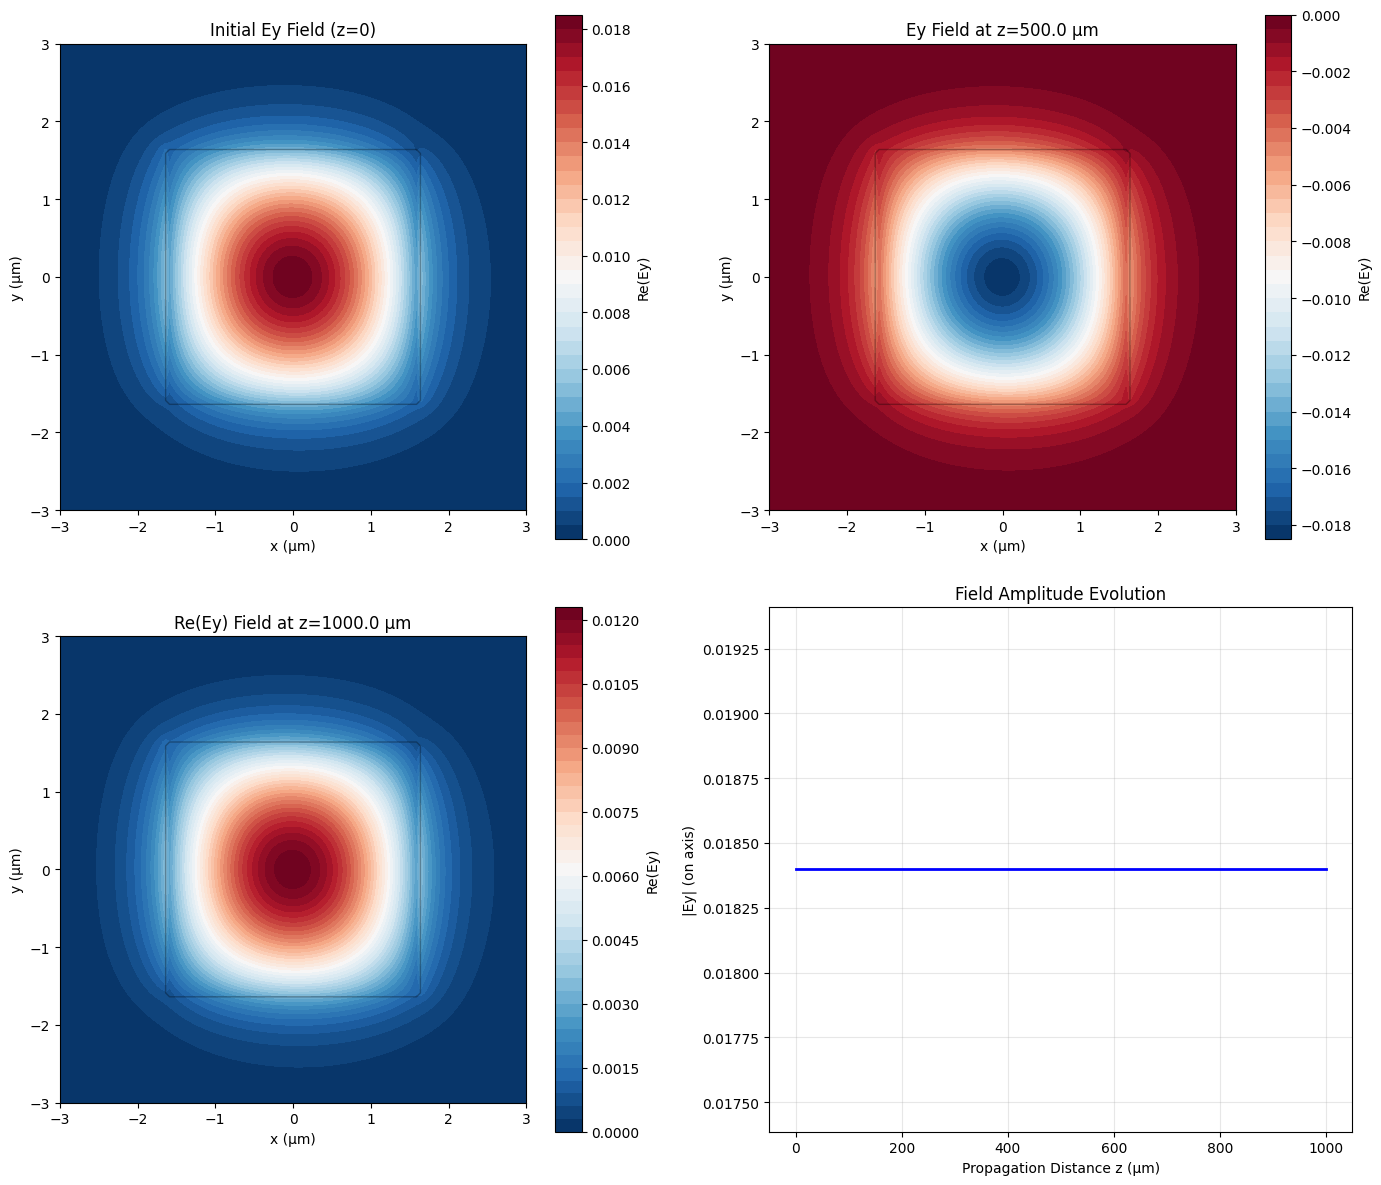

In [ ]:
# propagate along z
z_max_um = 1000.0
nz = 200
z_prop = np.linspace(0, z_max_um, nz)

mode = 0

Ex_evolution = []
for z in z_prop:
    Ex_evolution.append(Ey[mode, :]* np.exp(1j * beta[mode] * z)) 

Ex_evolution = np.array(Ex_evolution)

# plot Ex field as function of z
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Top left: Initial field
ax = axes[0, 0]
Ex_initial = Ex_evolution[0].reshape(nx, ny)
cf = ax.contourf(X_um, Y_um, np.real(Ex_initial), levels=40, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='Re(Ey)')
cs = ax.contour(X_um, Y_um, n[:, :, 1], levels=np.unique(n[:, :, 1]), colors='k', linewidths=1.0, alpha=0.3)
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Initial Ey Field (z=0)')
ax.set_aspect('equal')

# Top right: Field at z_max/2
ax = axes[0, 1]
Ex_mid = Ex_evolution[nz//2].reshape(nx, ny)
cf = ax.contourf(X_um, Y_um, np.real(Ex_mid), levels=40, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='Re(Ey)')
cs = ax.contour(X_um, Y_um, n[:, :, 1], levels=np.unique(n[:, :, 1]), colors='k', linewidths=1.0, alpha=0.3)
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title(f'Ey Field at z={z_max_um/2:.1f} µm')
ax.set_aspect('equal')

# Bottom left: Longitudinal plot (field vs z along x-axis)
ax = axes[1, 0]
# Extract field along x-axis (y = 0) as function of z
y_center_idx = ny // 2
field_vs_z_x = np.real(Ex_evolution[:, :, y_center_idx])  # shape: (nz, nx)
cf = ax.contourf(X_um[:, y_center_idx], z_prop, field_vs_z_x, levels=40, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='Re(Ey)')
ax.set_xlabel('x (µm)')
ax.set_ylabel('Propagation Distance z (µm)')
ax.set_title('Longitudinal View: Re(Ey) vs z along x-axis')

# Bottom right: On-axis field vs z
ax = axes[1, 1]
center_idx = nx * (ny // 2) + (nx // 2)
Ex_on_axis = np.abs(Ex_evolution[:, center_idx])
ax.plot(z_prop, Ex_on_axis, 'b-', linewidth=2)
ax.set_xlabel('Propagation Distance z (µm)')
ax.set_ylabel('|Ey| (on axis)')
ax.set_title('Field Amplitude Evolution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- It is important to emphasis that waveguide modes are mostly a convenient coordinate system and an arbitrary field can be created by superimposing them 
- This means that we can load an arbitary image and propagate it allong the  

Solving eigenmodes on CPU
53.65291380882263 secs later we have the final solution.


C:\Users\philip.main\AppData\Local\Temp\ipykernel_21492\2401872981.py:21: RuntimeWarning: overflow encountered in exp
  Ex_z += E0[i] * np.exp(1j * beta[i] * z)
C:\Users\philip.main\AppData\Local\Temp\ipykernel_21492\2401872981.py:21: RuntimeWarning: invalid value encountered in multiply
  Ex_z += E0[i] * np.exp(1j * beta[i] * z)
C:\Users\philip.main\AppData\Local\Temp\ipykernel_21492\2401872981.py:21: RuntimeWarning: invalid value encountered in add
  Ex_z += E0[i] * np.exp(1j * beta[i] * z)


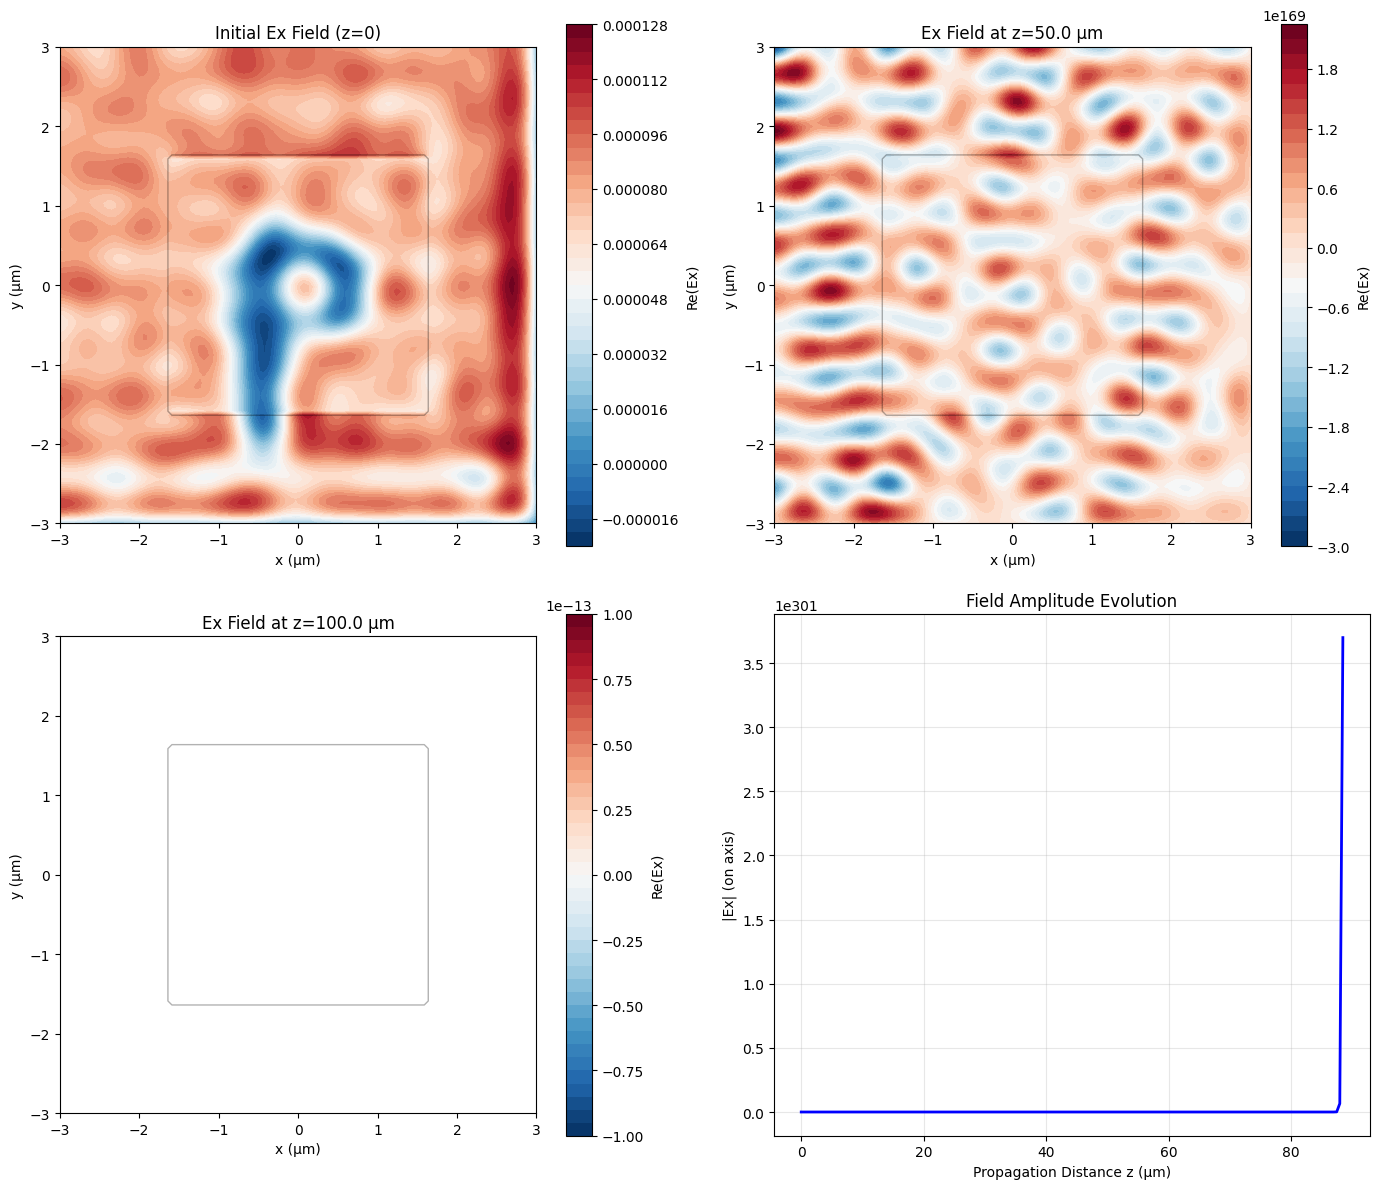

In [49]:
neigs = 500 
beta, Ex, Ey = ps.solve.solve(P, beta_in, neigs=neigs)

# load image from file 
emoji = plt.imread('p.bmp', format='bmp')
emoji = emoji[:, :, 0]
emoji = emoji / np.sum(emoji)
emoji_flat = emoji.flatten()

# propagate along z
z_max_um = 100.0
nz = 200
z_prop = np.linspace(0, z_max_um, nz)

Ex_evolution = []

E0 = [ np.sum(emoji_flat*Ex[i,:].conjugate())*Ex[i,:]  for i in range(len(beta))]
for z in z_prop:
    Ex_z = np.zeros(len(emoji_flat), dtype=complex)
    for i in range(len(beta)):
        Ex_z += E0[i] * np.exp(1j * beta[i] * z) 
    Ex_evolution.append(Ex_z)

Ex_evolution = np.array(Ex_evolution)

# plot Ex field as function of z
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Top left: Initial field
ax = axes[0, 0]
Ex_initial = Ex_evolution[0].reshape(nx, ny)
cf = ax.contourf(X_um, Y_um, np.real(Ex_initial), levels=40, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='Re(Ex)')
cs = ax.contour(X_um, Y_um, n[:, :, 1], levels=np.unique(n[:, :, 1]), colors='k', linewidths=1.0, alpha=0.3)
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Initial Ex Field (z=0)')
ax.set_aspect('equal')

# Top right: Field at z_max/2
ax = axes[0, 1]
Ex_mid = Ex_evolution[nz//2].reshape(nx, ny)
cf = ax.contourf(X_um, Y_um, np.real(Ex_mid), levels=40, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='Re(Ex)')
cs = ax.contour(X_um, Y_um, n[:, :, 1], levels=np.unique(n[:, :, 1]), colors='k', linewidths=1.0, alpha=0.3)
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title(f'Ex Field at z={z_max_um/2:.1f} µm')
ax.set_aspect('equal')

# Bottom left: Field at z_max
ax = axes[1, 0]
Ex_final = Ex_evolution[-1].reshape(nx, ny)
cf = ax.contourf(X_um, Y_um, np.real(Ex_final), levels=40, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='Re(Ex)')
cs = ax.contour(X_um, Y_um, n[:, :, 1], levels=np.unique(n[:, :, 1]), colors='k', linewidths=1.0, alpha=0.3)
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title(f'Ex Field at z={z_max_um:.1f} µm')
ax.set_aspect('equal')

# Bottom right: On-axis field vs z
ax = axes[1, 1]
center_idx = nx * (ny // 2) + (nx // 2)
Ex_on_axis = np.abs(Ex_evolution[:, center_idx])
ax.plot(z_prop, Ex_on_axis, 'b-', linewidth=2)
ax.set_xlabel('Propagation Distance z (µm)')
ax.set_ylabel('|Ex| (on axis)')
ax.set_title('Field Amplitude Evolution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Propagate the emoji field through the waveguide

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Propagation parameters
z_max_um = 50.0  # propagation distance
nz = 100  # number of z steps
z_prop = np.linspace(0, z_max_um, nz)

# Storage for field evolution
field_evolution = []

# Propagate each mode with its propagation constant beta
for iz, z in enumerate(z_prop):
    field_z = np.zeros((nx, ny), dtype=complex)
    
    for i in range(len(beta)):
        Ex_mode = Ex[i].reshape(nx, ny)
        Ey_mode = Ey[i].reshape(nx, ny)
        
        # Mode field magnitude
        E_mode_mag = np.sqrt(np.abs(Ex_mode)**2 + np.abs(Ey_mode)**2)
        E_mode_mag = E_mode_mag / (np.max(E_mode_mag) + 1e-12)
        
        # Propagate: E(z) = E(0) * exp(i*beta*z)
        phase = np.exp(1j * beta[i] * z)
        field_z += mode_coefficients[i] * E_mode_mag * phase
    
    field_evolution.append(np.real(field_z))

field_evolution = np.array(field_evolution)

# Create animation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: field at current z
ax = axes[0]
cf = ax.contourf(X_um, Y_um, field_evolution[0], levels=40, cmap='RdBu_r', vmin=-np.max(np.abs(field_evolution)), vmax=np.max(np.abs(field_evolution)))
plt.colorbar(cf, ax=ax, label='Re(E)')
cs = ax.contour(X_um, Y_um, n[:, :, 1], levels=np.unique(n[:, :, 1]), colors='k', linewidths=1.0, alpha=0.3)
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_aspect('equal')
title = ax.set_title(f'Emoji Field at z = 0.00 µm')

# Right: field on axis vs z (waterfall plot)
ax2 = axes[1]
center_idx = nx // 2
field_on_axis = field_evolution[:, center_idx, ny // 2]
line, = ax2.plot(z_prop, field_on_axis, 'b-', linewidth=2)
ax2.set_xlabel('Propagation Distance z (µm)')
ax2.set_ylabel('Field Amplitude (on axis)')
ax2.set_title('Field Evolution Along Waveguide')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()

def animate(frame: int):
    ax.clear()
    cf = ax.contourf(X_um, Y_um, field_evolution[frame], levels=40, cmap='RdBu_r', 
                     vmin=-np.max(np.abs(field_evolution)), vmax=np.max(np.abs(field_evolution)))
    cs = ax.contour(X_um, Y_um, n[:, :, 1], levels=np.unique(n[:, :, 1]), colors='k', linewidths=1.0, alpha=0.3)
    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    ax.set_aspect('equal')
    ax.set_title(f'Emoji Field at z = {z_prop[frame]:.2f} µm 😊')
    
    # Update marker on right plot
    ax2.clear()
    ax2.plot(z_prop, field_on_axis, 'b-', linewidth=2, alpha=0.3)
    ax2.plot(z_prop[:frame+1], field_on_axis[:frame+1], 'b-', linewidth=2)
    ax2.plot(z_prop[frame], field_on_axis[frame], 'ro', markersize=8)
    ax2.set_xlabel('Propagation Distance z (µm)')
    ax2.set_ylabel('Field Amplitude (on axis)')
    ax2.set_title('Field Evolution Along Waveguide')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax2.set_xlim(0, z_max_um)
    ax2.set_ylim(np.min(field_on_axis) * 1.1, np.max(field_on_axis) * 1.1)
    
    return ax, ax2

anim = FuncAnimation(fig, animate, frames=nz, interval=100, blit=False)
plt.close()

# Display animation
HTML(anim.to_jshtml())

- this doesn't lead to particularly interesting behaviour along the longditudinal direction 
- If we introduce a second waveguide however we can see light tunnelling between the two waveguides  

- In some instances the  physical interpretation (single mode fibre)
- Here you can still have any arbitrary field but most of the light would quickly scatter into free space 
- This principle of modes being a useful coordinate system to describe the fields can be 